In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , accuracy_score

In [3]:
from sklearn.metrics import (confusion_matrix, mean_squared_error,classification_report ,
roc_curve , roc_auc_score,mean_absolute_error)
import matplotlib.pyplot as plt

In [4]:
import numpy as np

In [5]:
import seaborn as sns

In [6]:
df = pd.read_csv('student-mat.csv')

In [7]:
print (df.shape , df.dtypes)

(395, 33) school                        str
sex                           str
age                         int64
address                       str
famsize                       str
Parrent_status                str
Mother_edu                  int64
Father_edu                  int64
Mother_job                    str
Father_job                    str
reason_to_chose_school        str
guardian                      str
traveltime                  int64
weekly_studytime            int64
failures                    int64
extra_edu_supp                str
family_edu_supp               str
extra_paid_class              str
extra_curr_activities         str
nursery                       str
Interested_in_higher_edu      str
internet_access               str
romantic_relationship         str
Family_quality_reln         int64
freetime_after_school       int64
goout_with_friends          int64
workday_alcohol_consum      int64
weekend_alcohol_consum      int64
health_status               int64
abse

In [14]:
#Qual a relação entre um bom aluno no G1 continuar sendo um bom aluno no G3?
# Calculo de regressão linear
x_train, x_test,y_train,y_test = train_test_split(
    df[["absences","weekly_studytime","failures","G1","G2"]],df[["G3"]],test_size=0.2,random_state=42)

# Treinamento
model_lreg = LinearRegression()

model_lreg.fit(x_train,y_train)

y_lreg_pred = model_lreg.predict(x_test)


In [24]:
# Metricas
rmse = np.sqrt(mean_squared_error(y_test,y_lreg_pred))
mae = mean_absolute_error(y_test,y_lreg_pred)
R2_score = model_lreg.score(x_test,y_test) 


print(f"Root Mean Squared Error: {rmse:.2f}") # O quão longe uma previsão esta do valor real, dependendo da unidade de medida
print(f"R2 Score: {R2_score:.4f}") # r^2

# Representão os valores da função linear | y = ax + b |
print(f"Coeficiente angular: {model_lreg.coef_}")
print(f"Coeficiente linear: {model_lreg.intercept_}")


Root Mean Squared Error: 2.11
R2 Score: 0.7822
Coeficiente angular: [[ 0.0392449  -0.07123057 -0.45581289  0.14446336  0.97961532]]
Coeficiente linear: [-1.6213124]


In [20]:
#Qual a relação entre um bom aluno no G1 continuar sendo um bom aluno no G3?
# Calculo de regressão linear
x_train_2, x_test_2,y_train_2,y_test_2 = train_test_split(
    df[["absences","weekly_studytime","failures"]],df[["G3"]],test_size=0.2,random_state=42)

# Treinamento
model_lreg_2 = LinearRegression()

model_lreg_2.fit(x_train_2,y_train_2)

y_lreg_pred_2 = model_lreg_2.predict(x_test_2)


In [23]:
# Metricas
rmse_2 = np.sqrt(mean_squared_error(y_test_2,y_lreg_pred_2))
mae_2 = mean_absolute_error(y_test_2,y_lreg_pred_2)
R2_score_2 = model_lreg_2.score(x_test_2,y_test_2) 

print(f"Root Mean Squared Error: {rmse_2:.2f}") # O quão longe uma previsão esta do valor real, dependendo da unidade de medida
print(f"R2 Score: {R2_score_2:.4f}") # r^2

# Representão os valores da função linear | y = ax + b |
print(f"Coeficiente angular: {model_lreg_2.coef_}")
print(f"Coeficiente linear: {model_lreg_2.intercept_}")


Root Mean Squared Error: 4.46
R2 Score: 0.0307
Coeficiente angular: [[ 0.04129383  0.51317701 -2.26800583]]
Coeficiente linear: [9.79217976]


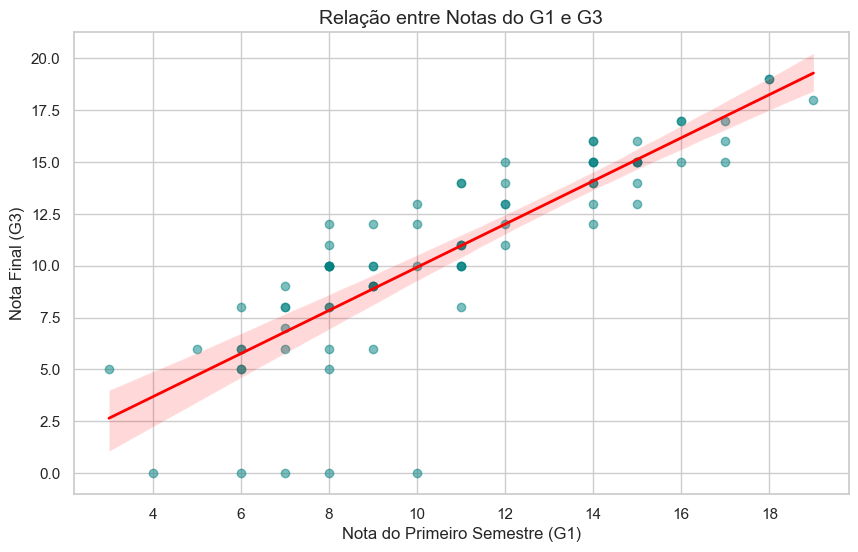

In [16]:
# Configurando o estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Criando o gráfico de dispersão com a linha de regressão
sns.regplot(x=x_test["G1"], y=y_test["G3"], 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'red', 'lw':2})

# Personalização
plt.title('Relação entre Notas do G1 e G3', fontsize=14)
plt.xlabel('Nota do Primeiro Semestre (G1)', fontsize=12)
plt.ylabel('Nota Final (G3)', fontsize=12)

plt.show()

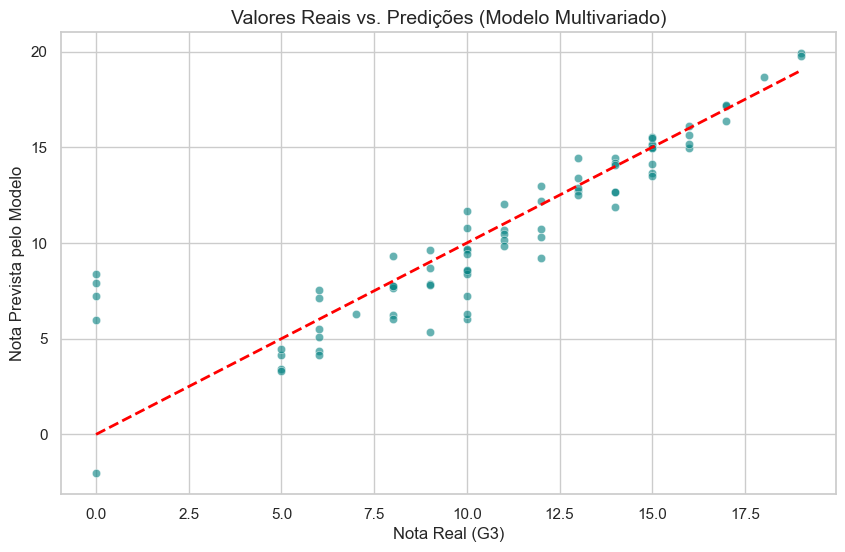

In [18]:
# Gerando as predições do seu modelo
y_pred = y_lreg_pred.flatten()  # Flatten para garantir que seja um array 1D

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test["G3"], y=y_pred, alpha=0.6, color='teal')

# Linha de referência (o ideal seria predição == real)
plt.plot([y_test["G3"].min(), y_test["G3"].max()], 
         [y_test["G3"].min(), y_test["G3"].max()], 
         color='red', lw=2, linestyle='--')

plt.title('Valores Reais vs. Predições (Modelo Multivariado)', fontsize=14)
plt.xlabel('Nota Real (G3)', fontsize=12)
plt.ylabel('Nota Prevista pelo Modelo', fontsize=12)
plt.show()